### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt

In [2]:
#setup log file 
logging.basicConfig(
    filename="preprocessin_log.log",
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [3]:
try:
    df = pd.read_csv("../dataset/default of credit card clients.csv", header=1)
    print("Dataset loaded successfully")
except Exception as e:
    print("Error loading dataset:", e)

Dataset loaded successfully


In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
#remove unnecessary column
def drop_id(df):
    try:
        df = df.drop("ID", axis=1)
        return df
    except Exception as e:
        logging.error(f"Error dropping ID column: {e}")
        print("Error dropping ID column")

In [6]:
df = drop_id(df)

In [7]:
df.tail()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,50000,1,2,1,46,0,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [8]:
#fix education categories
def clean_education(df):
    try:
        df["EDUCATION"] = df["EDUCATION"].replace([0,5,6],4)
        return df
    except Exception as e:
        logging.error(f"Error cleaning education column: {e}")
        print("Error cleaning education column")

In [9]:
df = clean_education(df)

In [10]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [11]:
#fix value for marrigae column
def clean_marriage(df):
    try:
        df["MARRIAGE"] = df["MARRIAGE"].replace(0,3)
        return df
    except Exception as e:
        logging.error(f"Error cleaning marriage column: {e}")
        print("Error cleaning marriage column")
        

In [12]:
df = clean_marriage(df)

In [13]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [14]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

### Feature Engineering

In [15]:
# 1. average bill amount
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)

# 2. average payment amount
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
df["AVG_PAY_AMT"] = df[pay_amt_cols].mean(axis=1)

# 3. total delay months
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df["TOTAL_DELAY_MONTHS"] = (df[pay_status_cols] > 0).sum(axis=1)

# 4. maximum delay
df["MAX_DELAY"] = df[pay_status_cols].max(axis=1)

# 5. average credit utilization
df["AVG_UTILIZATION"] = df[bill_cols].mean(axis=1) / (df["LIMIT_BAL"] + 1)

# 6. payment ratio
df["PAYMENT_RATIO"] = df["AVG_PAY_AMT"] / (df["AVG_BILL_AMT"] + 1)

In [16]:
# display new features
new_features = ["AVG_BILL_AMT", "AVG_PAY_AMT", "TOTAL_DELAY_MONTHS", "MAX_DELAY", "AVG_UTILIZATION", "PAYMENT_RATIO"]

In [17]:
df[new_features].head()

,AVG_BILL_AMT,AVG_PAY_AMT,TOTAL_DELAY_MONTHS,MAX_DELAY,AVG_UTILIZATION,PAYMENT_RATIO
0,1284.000000,114.833333,2,2,0.064197,0.089364
1,2846.166667,833.333333,2,2,0.023718,0.292689
2,16942.166667,1836.333333,0,0,0.188244,0.108382
3,38555.666667,1398.000000,0,0,0.771098,0.036258
4,18223.166667,9841.500000,0,0,0.364456,0.540025


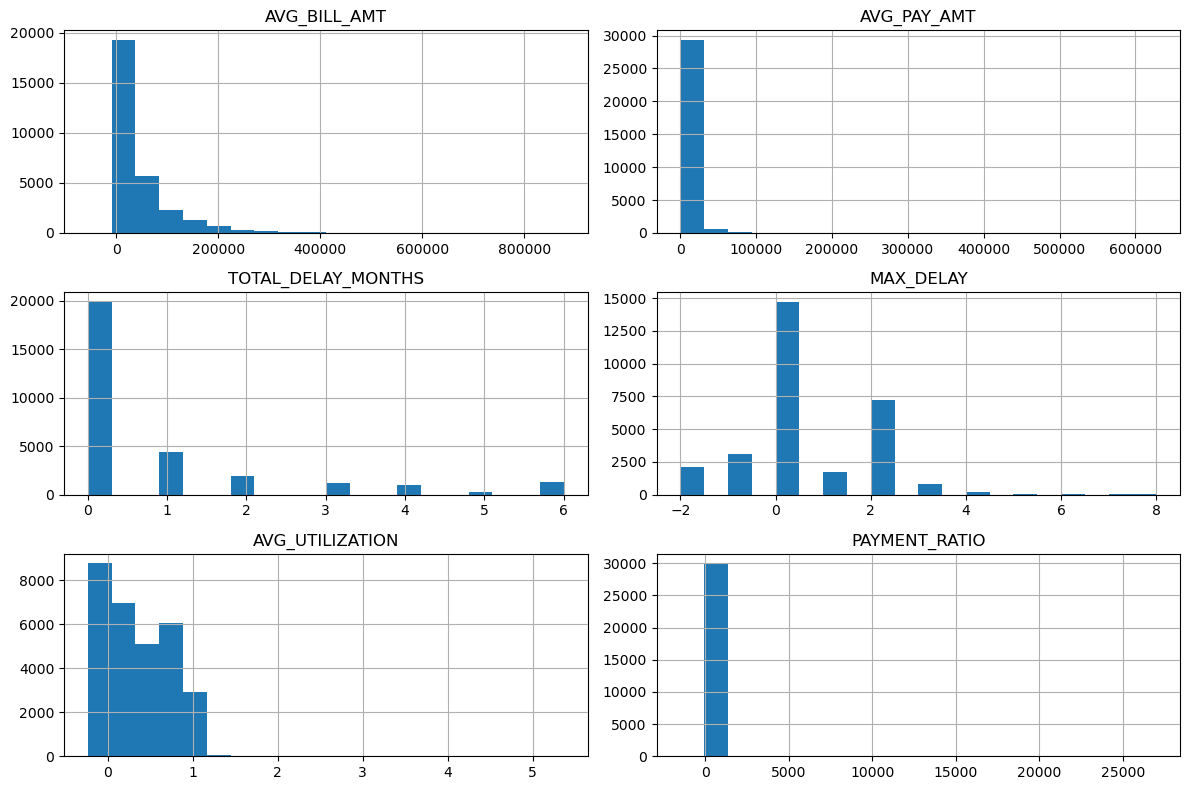

In [18]:
df[new_features].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

Note:

After preprocessing, new features were created to better represent customer financial behavior and payment patterns.

1. AVG_BILL_AMT shows the average credit card bill amount across the last six months. The histogram shows most customers have relatively low average bills, while a small number have very high bills (right-skewed distribution).

2. AVG_PAY_AMT represents the average amount a customer pays toward their credit card balance. Most customers make small payments, with only a few making very large payments.

3. TOTAL_DELAY_MONTHS counts how many months a customer had payment delays. The distribution shows that many customers have 0 delay months, meaning they usually pay on time.

4. MAX_DELAY shows the highest delay value recorded for a customer. Most customers have low delay values, indicating generally good repayment behavior.

5. AVG_UTILIZATION measures how much of the credit limit customers use on average. Most customers use a small to moderate portion of their credit limit, while very high utilization is rare.

6. PAYMENT_RATIO compares the payment amount to the bill amount. Most values are small, showing that customers usually pay only part of their total bill each month.

Overall, these engineered features help describe spending behavior, repayment ability, and credit usage, which are important factors for predicting whether a customer will default on their credit card payment.

In [19]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
AVG_BILL_AMT                  0
AVG_PAY_AMT                   0
TOTAL_DELAY_MONTHS            0
MAX_DELAY                     0
AVG_UTILIZATION               0
PAYMENT_RATIO                 2
dtype: int64

In [20]:
df[df["PAYMENT_RATIO"].isnull()]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,AVG_BILL_AMT,AVG_PAY_AMT,TOTAL_DELAY_MONTHS,MAX_DELAY,AVG_UTILIZATION,PAYMENT_RATIO
13650,260000,1,2,1,53,-2,-2,-2,-2,-2,...,0,0,0,0,-1.0,0.0,0,-2,-0.000004,NaN
28804,360000,2,1,1,36,1,-2,-2,-2,-2,...,0,0,0,0,-1.0,0.0,1,1,-0.000003,NaN


In [21]:
df["PAYMENT_RATIO"] = df["PAYMENT_RATIO"].fillna(0)

In [22]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
AVG_BILL_AMT                  0
AVG_PAY_AMT                   0
TOTAL_DELAY_MONTHS            0
MAX_DELAY                     0
AVG_UTILIZATION               0
PAYMENT_RATIO                 0
dtype: int64

Note: Missing values in the PAYMENT_RATIO feature were handled by replacing them with 0 to ensure the dataset remains complete for model training.

In [23]:
#encoding categorical values
df = pd.get_dummies(df, columns=["SEX", "EDUCATION", "MARRIAGE"], drop_first=True)

dummy_cols = [col for col in df.columns if col.startswith("SEX_") or col.startswith("EDUCATION_") or col.startswith("MARRIAGE_")]
df[dummy_cols] = df[dummy_cols].astype(int)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (30000, 33)


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,TOTAL_DELAY_MONTHS,MAX_DELAY,AVG_UTILIZATION,PAYMENT_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,2,2,0.064197,0.089364,1,1,0,0,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,2,2,0.023718,0.292689,1,1,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,0,0,0.188244,0.108382,1,1,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,0,0,0.771098,0.036258,1,1,0,0,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,0,0,0.364456,0.540025,0,1,0,0,0,0


Note:

Although the variables SEX, EDUCATION, and MARRIAGE are stored as integers in the dataset, they represent categorical values rather than true numerical quantities. Therefore, encoding was applied to prevent machine learning models from interpreting these codes as ordered numerical values.

In [24]:
df.to_csv("../dataset/clean_credit_data.csv", index=False)

### Overall Summary

1. Removed unnecessary columns such as ID because they do not contribute to prediction.

2. Cleaned categorical variables EDUCATION and MARRIAGE by replacing invalid values with a common category.

3. Checked the dataset for missing values to ensure data quality.

4. Performed feature engineering to create new variables that better represent customer financial behavior.

5. Created features such as AVG_BILL_AMT, AVG_PAY_AMT, TOTAL_DELAY_MONTHS, MAX_DELAY, AVG_UTILIZATION, and PAYMENT_RATIO.

6. These new features summarize spending patterns, payment behavior, and credit usage.

7. Applied encoding to categorical variables (SEX, EDUCATION, MARRIAGE) so they can be used by machine learning models.

8. Verified that the dataset contains no missing values after transformations.

9. Saved the cleaned and processed dataset as clean_credit_data.csv for use in the modeling stage.